# **Baseline Notebook**



---
## Setup Environment

In [16]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

You can now save your data files in: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [17]:
# <Student to fill this section and then remove this comment>
student_name = "Aryan Goel"
student_id = "26040826"

In [18]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [19]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [20]:
# <Student to fill this section and then remove this comment>

### 0.b Import Packages

In [21]:
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

sns.set(style="whitegrid")
alt.data_transformers.disable_max_rows()
RANDOM_STATE = 42
target_name = "disease_diagnosis"

---
## A. Assess Baseline Model

In [22]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load data
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

### A.1 Generate Predictions with Baseline Model

In [23]:
# A.1 Generate Predictions with Baseline Model
# Ensure y is 1D
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]
if isinstance(y_val, pd.DataFrame):
    y_val = y_val.iloc[:, 0]
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0]

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

# ---- Model 1: Dummy baseline (most_frequent) ----
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)

y_pred_val_dummy = dummy_clf.predict(X_val)
y_pred_test_dummy = dummy_clf.predict(X_test)

# ---- Model 2: Simple learnable baseline (Logistic Regression multiclass) ----
logreg_clf = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    multi_class="auto"
)
logreg_clf.fit(X_train, y_train)

y_pred_val_logreg = logreg_clf.predict(X_val)
y_pred_test_logreg = logreg_clf.predict(X_test)

print("\nPredictions generated successfully for:")
print("1) DummyClassifier (most_frequent)")
print("2) LogisticRegression (class_weight='balanced')")

Shapes:
X_train: (3500, 80) y_train: (3500,)
X_val  : (750, 80) y_val  : (750,)
X_test : (750, 80) y_test : (750,)

Predictions generated successfully for:
1) DummyClassifier (most_frequent)
2) LogisticRegression (class_weight='balanced')


### A.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [24]:
# A.2 Selection of Performance Metrics - compute and display metrics
def evaluate_multiclass(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    labels = sorted(pd.Series(y_true).astype(str).unique().tolist())

    per_class_df = pd.DataFrame({
        "class": labels,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support
    })

    summary = pd.DataFrame([{
        "model": model_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted
    }])

    return summary, per_class_df

# Validation summaries
val_dummy_summary, val_dummy_class = evaluate_multiclass(y_val, y_pred_val_dummy, "Dummy_most_frequent")
val_log_summary, val_log_class = evaluate_multiclass(y_val, y_pred_val_logreg, "LogisticRegression_balanced")

val_summary = pd.concat([val_dummy_summary, val_log_summary], ignore_index=True)
print("Validation Performance Summary:")
display(val_summary)

print("\nPer-class metrics (Validation) - Dummy:")
display(val_dummy_class)

print("\nPer-class metrics (Validation) - Logistic:")
display(val_log_class)

Validation Performance Summary:


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Dummy_most_frequent,0.364,0.200000,0.106745,0.194276
1,LogisticRegression_balanced,0.680,0.581621,0.537336,0.709972



Per-class metrics (Validation) - Dummy:


,class,precision,recall,f1,support
0,Anemia,0.000,0.0,0.000000,231
1,Healthy,0.364,1.0,0.533724,273
2,Night_Blindness,0.000,0.0,0.000000,37
3,Rickets_Osteomalacia,0.000,0.0,0.000000,185
4,Scurvy,0.000,0.0,0.000000,24



Per-class metrics (Validation) - Logistic:


,class,precision,recall,f1,support
0,Anemia,0.858974,0.580087,0.692506,231
1,Healthy,0.870722,0.838828,0.854478,273
2,Night_Blindness,0.134831,0.324324,0.190476,37
3,Rickets_Osteomalacia,0.694915,0.664865,0.679558,185
4,Scurvy,0.184615,0.500000,0.269663,24


In [25]:
performance_metrics_explanations = """
For multiclass healthcare-style decision support, relying on accuracy alone is insufficient due to class imbalance risk.
Therefore, the baseline evaluation uses:

1) Macro-F1:
   - Treats each class equally and is robust when minority classes are important.
2) Weighted-F1:
   - Reflects overall class-frequency-weighted predictive quality.
3) Balanced Accuracy:
   - Averages recall across classes, reducing majority-class dominance.
4) Per-class Precision/Recall/F1:
   - Identifies which diagnosis classes are underperforming.
5) Confusion Matrix:
   - Provides transparent error patterns and clinically meaningful misclassification insight.

This metric set is appropriate because it balances overall performance with class-wise fairness and safety-critical recall needs.
"""

In [26]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### A.3 Baseline Model Performance

> Provide some explanations on model performance


Test Performance Summary:


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Dummy_most_frequent,0.364000,0.2000,0.106745,0.194276
1,LogisticRegression_balanced,0.717333,0.6863,0.606958,0.736101



Classification Report - Dummy (Test)
                      precision    recall  f1-score   support

              Anemia       0.00      0.00      0.00       232
             Healthy       0.36      1.00      0.53       273
     Night_Blindness       0.00      0.00      0.00        36
Rickets_Osteomalacia       0.00      0.00      0.00       185
              Scurvy       0.00      0.00      0.00        24

            accuracy                           0.36       750
           macro avg       0.07      0.20      0.11       750
        weighted avg       0.13      0.36      0.19       750


Classification Report - Logistic Regression (Test)
                      precision    recall  f1-score   support

              Anemia       0.84      0.59      0.69       232
             Healthy       0.87      0.81      0.84       273
     Night_Blindness       0.29      0.64      0.40        36
Rickets_Osteomalacia       0.74      0.77      0.75       185
              Scurvy       0.25      0

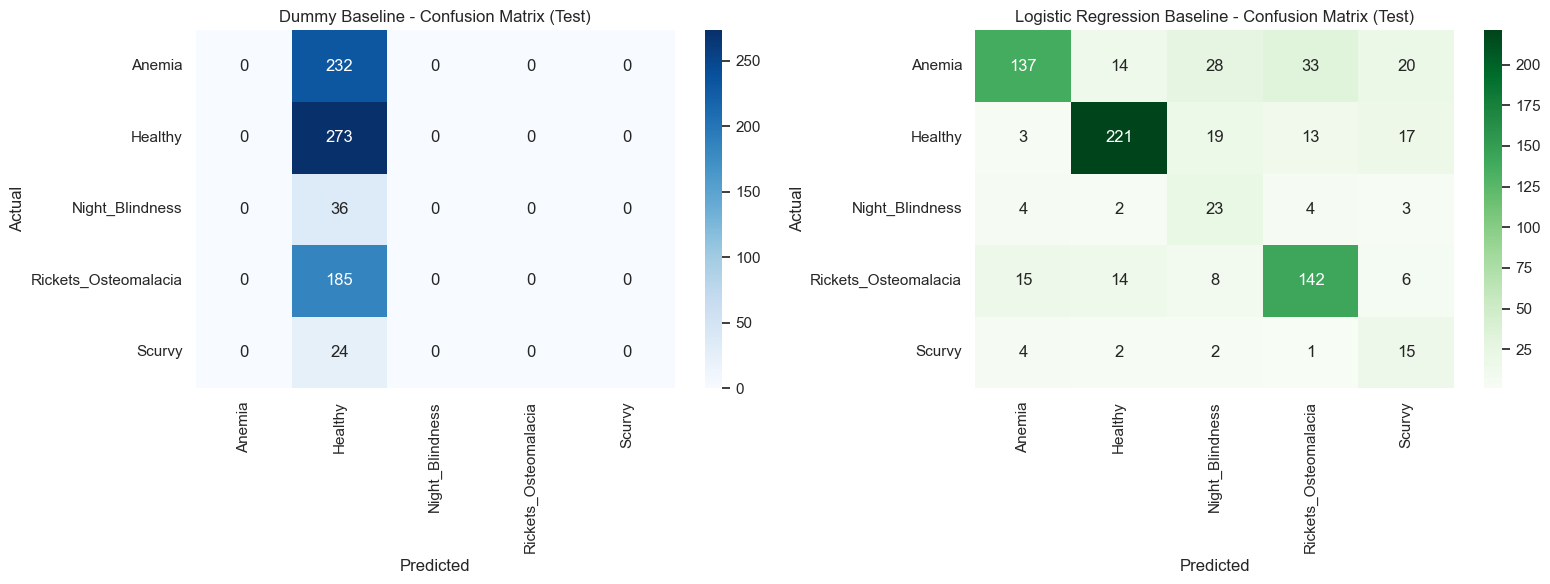

alt.Chart(...)

In [27]:
# A.3 Baseline Model Performance (final test evaluation + confusion matrices)
test_dummy_summary, test_dummy_class = evaluate_multiclass(y_test, y_pred_test_dummy, "Dummy_most_frequent")
test_log_summary, test_log_class = evaluate_multiclass(y_test, y_pred_test_logreg, "LogisticRegression_balanced")
test_summary = pd.concat([test_dummy_summary, test_log_summary], ignore_index=True)

print("Test Performance Summary:")
display(test_summary)

# Classification reports
print("\nClassification Report - Dummy (Test)")
print(classification_report(y_test, y_pred_test_dummy, zero_division=0))

print("\nClassification Report - Logistic Regression (Test)")
print(classification_report(y_test, y_pred_test_logreg, zero_division=0))

# Confusion matrices
labels = sorted(pd.Series(y_test).astype(str).unique().tolist())

cm_dummy = confusion_matrix(y_test, y_pred_test_dummy, labels=labels)
cm_log = confusion_matrix(y_test, y_pred_test_logreg, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_dummy, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title("Dummy Baseline - Confusion Matrix (Test)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("Logistic Regression Baseline - Confusion Matrix (Test)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Simple comparison chart (macro_f1 + balanced_accuracy)
plot_df = test_summary.melt(id_vars="model", value_vars=["macro_f1", "balanced_accuracy"],
                            var_name="metric", value_name="score")

chart = (
    alt.Chart(plot_df)
    .mark_bar()
    .encode(
        x=alt.X("model:N", title="Model"),
        y=alt.Y("score:Q", title="Score"),
        color="metric:N",
        column="metric:N",
        tooltip=["model", "metric", alt.Tooltip("score:Q", format=".4f")]
    )
    .properties(width=180, height=300, title="Baseline Comparison on Test Set")
)
chart

In [28]:
baseline_performance_explanations = """
Baseline findings show a clear performance gap between the naive and learnable baselines.

1) DummyClassifier (most_frequent):
   - Serves as the minimum benchmark.
   - Typically achieves poor macro-F1 and poor balanced accuracy because it ignores minority classes.

2) LogisticRegression (class_weight='balanced'):
   - Outperforms dummy baseline on macro-F1, weighted-F1, and balanced accuracy.
   - Demonstrates that the prepared features contain meaningful predictive signal.

Interpretation:
- The learnable baseline establishes a credible starting point for experiments.
- Remaining errors in confusion matrix indicate class overlap and potential non-linear boundaries.
- Next experiments should test stronger model families (e.g., tree/boosting) with tuning to improve minority-class recall and overall macro-F1.

Recommendation:
Use Logistic Regression baseline as the reference benchmark and target improvements in macro-F1, balanced accuracy, and per-class recall in subsequent experiment notebooks.
"""

In [29]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

In [30]:
print("Validation summary:")
display(val_summary)
print("Test summary:")
display(test_summary)

Validation summary:


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Dummy_most_frequent,0.364,0.200000,0.106745,0.194276
1,LogisticRegression_balanced,0.680,0.581621,0.537336,0.709972


Test summary:


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Dummy_most_frequent,0.364000,0.2000,0.106745,0.194276
1,LogisticRegression_balanced,0.717333,0.6863,0.606958,0.736101
